In [1]:
data_dir = '../data/Snake Images'

In [2]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [3]:
data_dir = '../data'
for root, dirs, files in os.walk(data_dir):
    level = root.replace(data_dir, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level >= 2:
        print(f'{indent}  ... {len(files)} files')

data/
  Snake Images/
    test/
      ... 0 files
      Non Venomous/
        ... 128 files
      Venomous/
        ... 141 files
    train/
      ... 0 files
      Non Venomous/
        ... 715 files
      Venomous/
        ... 1060 files


In [8]:
data_dir = '../data/Snake Images'

counts = {}
for split in ['train', 'test']:
    for label in ['Venomous', 'Non Venomous']:
        path = os.path.join(data_dir, split, label)
        if os.path.exists(path):
            counts[f'{split}_{label}'] = len(os.listdir(path))
print(counts)

{'train_Venomous': 1060, 'train_Non Venomous': 715, 'test_Venomous': 141, 'test_Non Venomous': 128}


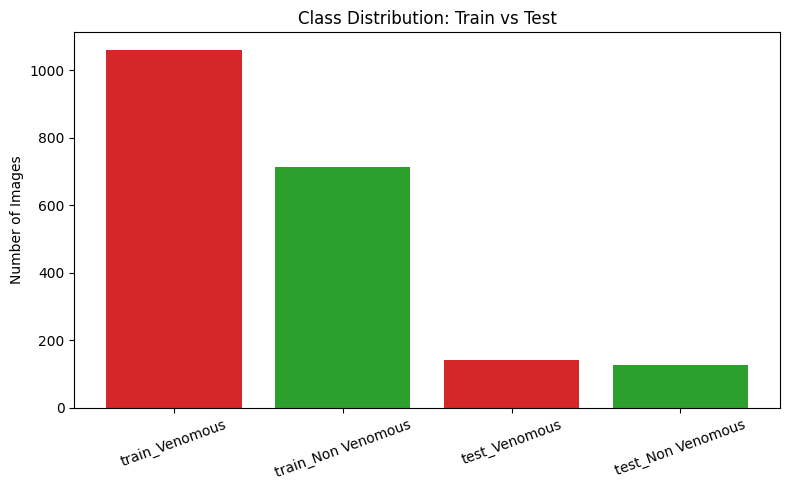

In [9]:
labels = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(8,5))
plt.bar(labels, values, color=['#d62728','#2ca02c','#d62728','#2ca02c'])
plt.title('Class Distribution: Train vs Test')
plt.ylabel('Number of Images')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../notebooks/class_distribution.png', dpi=150)
plt.show()

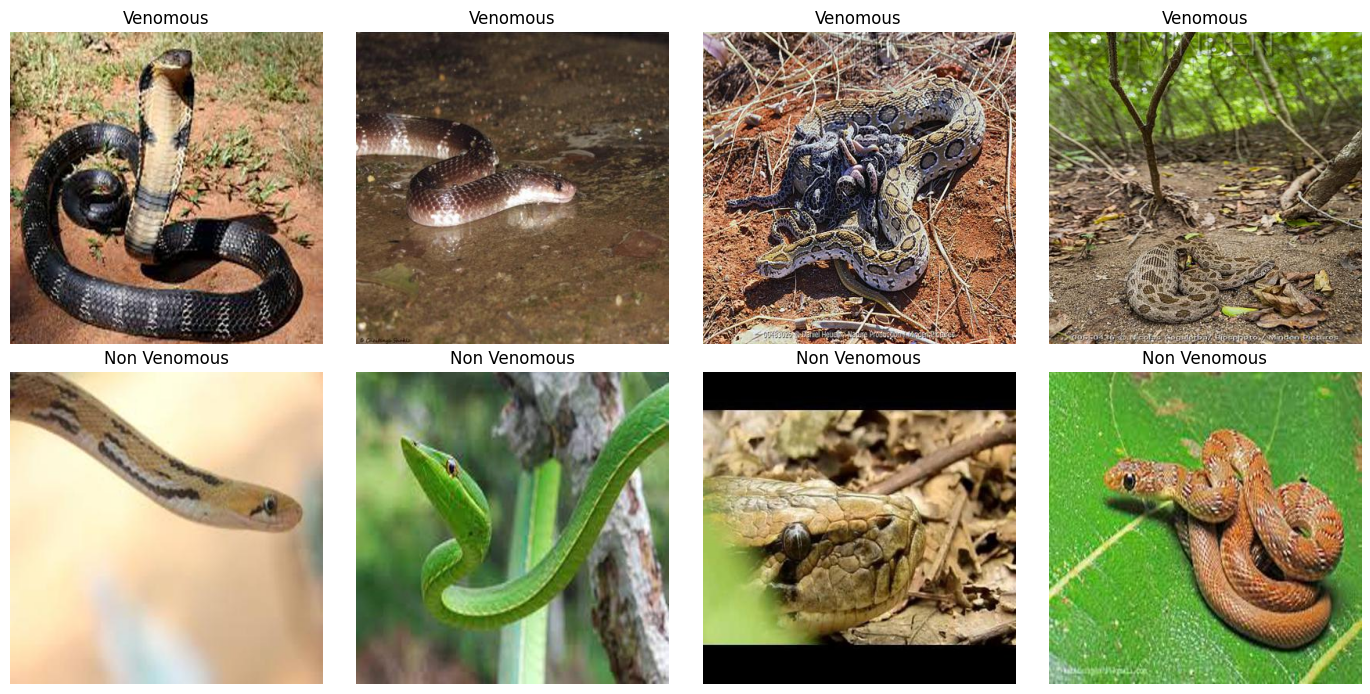

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(14,7))
for i, label in enumerate(['Venomous', 'Non Venomous']):
    folder = os.path.join(data_dir, 'train', label)
    files = os.listdir(folder)[:4]
    for j, f in enumerate(files):
        img = Image.open(os.path.join(folder, f))
        axes[i,j].imshow(img)
        axes[i,j].set_title(label)
        axes[i,j].axis('off')
plt.tight_layout()
plt.savefig('../notebooks/sample_images.png', dpi=150)
plt.show()

In [12]:
sizes = []
for split in ['train', 'test']:
    for label in ['Venomous', 'Non-Venomous']:
        folder = os.path.join(data_dir, split, label)
        if os.path.exists(folder):
            for f in os.listdir(folder):
                try:
                    img = Image.open(os.path.join(folder, f))
                    sizes.append(img.size)
                except Exception as e:
                    print(f'Corrupt file: {f} — {e}')
print('Unique sizes found:', set(sizes))

Unique sizes found: {(636, 593), (640, 445), (600, 399), (268, 188), (640, 454), (578, 305), (220, 282), (660, 371), (208, 140), (354, 530), (409, 252), (768, 1024), (650, 433), (400, 400), (800, 547)}
